In [10]:
%load_ext autoreload
%autoreload 2


import matplotlib.pyplot as plt
import numpy as np
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
def simulate_trajectories(
    T=10.0,
    dt=1e-3,
    n_traj=1000,
    a=1.0,
    b=1.0,
    sigma_z=1.0,
    n=1,
    x0=0.0,
    z0=0.0,
    seed=0,
):
    """
    Simulate multiple trajectories of:
        dx/dt = a*z - b*sin(x-c)

    x in [-pi*n, pi*n], reflecting boundaries
    z is a random walk
    """

    rng = np.random.default_rng(seed)

    steps = int(T / dt)
    t = np.linspace(0, T, steps)

    # Boundary and phase shift
    x_min = -np.pi * n
    x_max =  np.pi * n
    c = 0.0 if (n % 2 == 0) else np.pi

    # State
    x = np.full((n_traj,), x0, dtype=float)
    z = np.full((n_traj,), z0, dtype=float)

    # Store trajectories
    xs = np.zeros((steps, n_traj))
    zs = np.zeros((steps, n_traj))

    sqrt_dt = np.sqrt(dt)

    for k in range(steps):
        # Random walk update
        z += sigma_z * sqrt_dt * rng.standard_normal(n_traj)

        # x update
        x += dt * (a * z + b * np.sin(x - c))

        # Reflecting boundaries
        x = np.where(x > x_max, 2*x_max - x, x)
        x = np.where(x < x_min, 2*x_min - x, x)

        xs[k] = x
        zs[k] = z

    return t, xs, zs


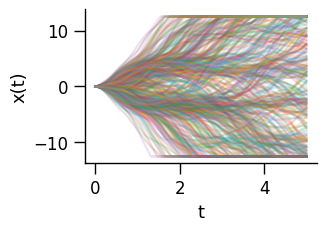

In [49]:
t, xs, zs = simulate_trajectories(
    T=5.0,
    dt=1e-3,
    n_traj=500,
    a=4,
    b=2.0,
    sigma_z=1.0,
    n=4,
)

fig, axs = plt.subplots(1, 1, figsize=(3, 2))

axs.plot(t, xs[:, :], alpha=0.2)
axs.set_xlabel("t")
axs.set_ylabel("x(t)")

format_plot(axs)


Decoder weight: 2.3070821739875838
Decoder intercept: -0.035064553288578236
Test R^2: 0.8968802179115629
(10000, 5000)


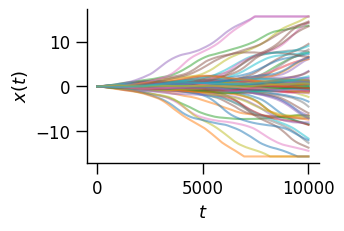

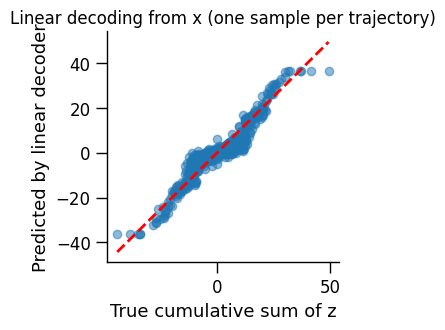

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# --------------------------
# 1. Simulation parameters
# --------------------------
T = 10.0
dt = 1e-3
n_traj = 5000  # more trajectories to have enough samples
a = 0.6
b = 1
sigma_z = 1.0
n = 5
x0 = 0.0
z0 = 0.0
seed = 0

rng = np.random.default_rng(seed)
steps = int(T / dt)
t = np.linspace(0, T, steps)

x_min = -np.pi * n
x_max = np.pi * n
c = 0.0 if (n % 2 == 0) else np.pi

# --------------------------
# 2. Simulate trajectories
# --------------------------
x = np.full((n_traj,), x0, dtype=float)
z = np.full((n_traj,), z0, dtype=float)

xs = np.zeros((steps, n_traj))
zs = np.zeros((steps, n_traj))

sqrt_dt = np.sqrt(dt)

for k in range(steps):
    z += sigma_z * sqrt_dt * rng.standard_normal(n_traj)
    x += dt * (a * z + b * np.sin(x - c))
    x = np.where(x > x_max, 2*x_max - x, x)
    x = np.where(x < x_min, 2*x_min - x, x)
    xs[k] = x
    zs[k] = z

# --------------------------
# 3. Compute cumulative sum of z
# --------------------------
s = np.cumsum(zs, axis=0) * dt  # integral of z

# --------------------------
# 4. Pick ONE sample per trajectory
# --------------------------
time_indices = rng.integers(0, steps, size=n_traj)
X_samples = xs[time_indices, np.arange(n_traj)].reshape(-1, 1)
y_samples = s[time_indices, np.arange(n_traj)].reshape(-1, 1)

# --------------------------
# 5. Train/test split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_samples, y_samples, test_size=0.2, random_state=seed
)

# --------------------------
# 6. Linear decoder
# --------------------------
decoder = LinearRegression(fit_intercept=True)
decoder.fit(X_train, y_train)

y_pred_test = decoder.predict(X_test)
r2 = r2_score(y_test, y_pred_test)

print("Decoder weight:", decoder.coef_[0,0])
print("Decoder intercept:", decoder.intercept_[0])
print("Test R^2:", r2)

print(xs.shape)

fig, axs = plt.subplots(1, 1, figsize=(3,2))
for i in range(100):
    axs.plot(np.arange(steps), xs[:, i], alpha=0.5)
axs.set_ylabel(r'$x(t)$')
axs.set_xlabel(r'$t$')
# axs.set_ylabel("Predicted by linear decoder")
# axs.set_title("Linear decoding from x (one sample per trajectory)")
format_plot(axs)

# --------------------------
# 7. Plot true vs predicted y
# --------------------------
fig, axs = plt.subplots(1, 1, figsize=(3,3))
axs.scatter(y_test, y_pred_test, alpha=0.5)
axs.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
axs.set_xlabel("True cumulative sum of z")
axs.set_ylabel("Predicted by linear decoder")
axs.set_title("Linear decoding from x (one sample per trajectory)")
format_plot(axs)


n=1, max R^2=0.868
n=2, max R^2=0.726
n=3, max R^2=0.901
n=4, max R^2=0.897
n=5, max R^2=0.941
n=6, max R^2=0.943
n=7, max R^2=0.961


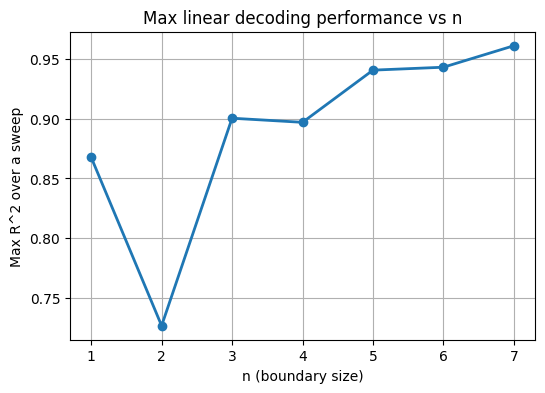

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# --------------------------
# 1. Fixed simulation parameters
# --------------------------
T = 10.
dt = 1e-3
n_traj = 2000       # number of trajectories per run
b = 1.0
sigma_z = 1.0
x0 = 0.0
z0 = 0.0
seed = 0

rng = np.random.default_rng(seed)
steps = int(T / dt)

# Sweep parameters
n_values = [1, 2, 3, 4, 5, 6, 7]       # different boundary sizes
a_values = np.linspace(0.1, 1.0, 20)  # sweep over a

# Store max R^2 for each n
max_r2_per_n = []

# --------------------------
# 2. Loop over n
# --------------------------
for n in n_values:
    r2s = []
    x_min = -np.pi * n
    x_max = np.pi * n
    c = 0.0 if (n % 2 == 0) else np.pi

    # ----------------------
    # 3. Loop over a
    # ----------------------
    for a in a_values:
        # Simulate trajectories
        x = np.full((n_traj,), x0, dtype=float)
        z = np.full((n_traj,), z0, dtype=float)
        xs = np.zeros((steps, n_traj))
        zs = np.zeros((steps, n_traj))
        sqrt_dt = np.sqrt(dt)

        for k in range(steps):
            z += sigma_z * sqrt_dt * rng.standard_normal(n_traj)
            x += dt * (a * z + b * np.sin(x - c))
            x = np.where(x > x_max, 2*x_max - x, x)
            x = np.where(x < x_min, 2*x_min - x, x)
            xs[k] = x
            zs[k] = z

        # Cumulative sum of z
        s = np.cumsum(zs, axis=0) * dt

        # Pick one random sample per trajectory
        time_indices = rng.integers(0, steps, size=n_traj)
        X_samples = xs[time_indices, np.arange(n_traj)].reshape(-1, 1)
        y_samples = s[time_indices, np.arange(n_traj)].reshape(-1, 1)

        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X_samples, y_samples, test_size=0.2, random_state=seed
        )

        # Linear decoder
        decoder = LinearRegression(fit_intercept=True)
        decoder.fit(X_train, y_train)
        y_pred_test = decoder.predict(X_test)
        r2 = r2_score(y_test, y_pred_test)
        r2s.append(r2)

    # Store max R^2 for this n
    max_r2 = max(r2s)
    max_r2_per_n.append(max_r2)
    print(f"n={n}, max R^2={max_r2:.3f}")

# --------------------------
# 4. Plot max R^2 vs n
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(n_values, max_r2_per_n, 'o-', lw=2)
plt.xlabel("n (boundary size)")
plt.ylabel("Max R^2 over a sweep")
plt.title("Max linear decoding performance vs n")
plt.grid(True)
plt.show()
